In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import sys
import pathlib
root = pathlib.Path('.').resolve().parent
sys.path.append(str(root))
np.random.seed(0)

from plotting import plot_density

from src.haldensity.estimation.base_estimator import BaseEstimator
from src.haldensity.estimation import CVXPYEstimator
from src.haldensity.cross_validation.optuna_hyperparam_selector import OptunaHyperparameterTuner
from src.haldensity.utils import TruncatedGMM


Fitting CVXPYEstimator ...
Finished fitting CVXPYEstimator ...


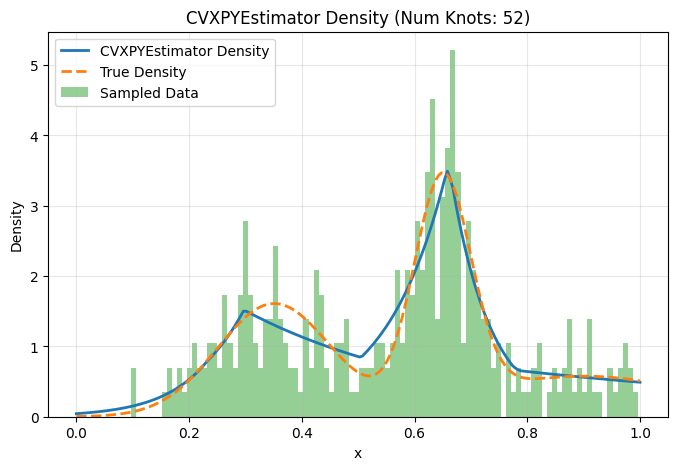

In [2]:
sampler_params = {
    "components": [
        {'mean': 0.35, 'std': 0.1, 'lower': 0.0, 'upper': 1.0},
        {'mean': 0.65, 'std': 0.05, 'lower': 0.0, 'upper': 1.0},
        {'mean': 0.9, 'std': 0.2, 'lower': 0.0, 'upper': 1.0}
    ],
    "weights": [0.4, 0.4, 0.2]
}

sampler = TruncatedGMM(
    **sampler_params,
)

n_samples = 400

sampler_setup = {
    "sampler": sampler.__class__.__name__,
    "sampler_params": sampler_params,
    "n_samples": n_samples
}

data_all = pd.DataFrame({
    'W1': np.concatenate([
        sampler.generate_samples(n_samples)
    ])
})

# cut data into training and validation sets
data = data_all[:4 * n_samples // 5]
data_val = data_all[4 * n_samples // 5:]

estimator_params = {
    'basis_order':1,
    'norm_constraint': 76.36874512445132,
}

estimator = CVXPYEstimator(**estimator_params)

estimator_setup = {
    "estimator": estimator.__class__.__name__,
    "estimator_params": estimator_params,
}

fit_params = {
    'data': data,
}

# fitting the estimator
print(f"Fitting {estimator.__class__.__name__} ...")
estimator.fit(**fit_params)
print(f"Finished fitting {estimator.__class__.__name__} ...")

# Get results
grid_points, estimated_density = estimator.get_density()
estimation_results = estimator.get_results()

# Compute true density vs estimated density overlaid with training histogram
plot_density(
    grid_points=grid_points,
    true_density=sampler.compute_density(grid_points),
    estimated_density=estimator.get_density_at_points(grid_points),
    title=f"{estimator.__class__.__name__} Density (Num Knots: {estimation_results.get('n_selected_knots', 'N/A')})",
    method_label=f"{estimator.__class__.__name__} Density",
    hist_data=data["W1"],
    hist_bins=100,
    hist_alpha=0.5,
    hist_label="Sampled Data",
    show=True
)

In [3]:
from src.haldensity.targeting import (
    CDFTargetLearner,
    SurvivalTargetLearner,
    MomentsTargetLearner,
    MedianTargetLearner,
    cdf_estimand_variance,
    survival_estimand_variance,
    moments_estimand_variance,
    median_estimand_variance,
)

from src.haldensity.utils.density_computations import (
    generic_compute_cdf_from_density,
    generic_compute_survival_from_density,
    generic_compute_moment_from_density,
    generic_compute_median_from_density,
)

In [4]:
# ============================
# CONFIGURE TARGET LEARNER HERE
# ============================
# Choose one: "CDF", "Survival", "Moments", "Median"

TARGET_TYPE = "Survival"

In [5]:

# Configure targeting parameters based on type
if TARGET_TYPE == "CDF":
    TargetLearner = CDFTargetLearner
    targeting_M_step = lambda **kwargs: TargetLearner(
        norm_constraint=kwargs.pop('norm_constraint', 100),
        basis_order=kwargs.pop('basis_order', 0)
    ).run_m_step(**kwargs)
    estimand_variance = cdf_estimand_variance
    statistic_from_density = generic_compute_cdf_from_density
    targeting_points = np.linspace(0.01, 0.99, 20)
    targeting_kwargs = {'targeting_points': targeting_points}
    
elif TARGET_TYPE == "Survival":
    TargetLearner = SurvivalTargetLearner
    targeting_M_step = lambda **kwargs: TargetLearner(
        norm_constraint=kwargs.pop('norm_constraint', 100),
        basis_order=kwargs.pop('basis_order', 0)
    ).run_m_step(**kwargs)
    estimand_variance = survival_estimand_variance
    statistic_from_density = generic_compute_survival_from_density
    targeting_points = np.linspace(0.01, 0.99, 20)
    targeting_kwargs = {'targeting_points': targeting_points}
    
elif TARGET_TYPE == "Moments":
    TargetLearner = MomentsTargetLearner
    targeting_M_step = lambda **kwargs: TargetLearner(
        norm_constraint=kwargs.pop('norm_constraint', 100),
        basis_order=kwargs.pop('basis_order', 0)
    ).run_m_step(**kwargs)
    estimand_variance = moments_estimand_variance
    statistic_from_density = lambda grid_points, density: (
        generic_compute_moment_from_density(grid_points, density, moment_order=2), 
        grid_points
    )
    targeting_points = None
    moment_order = 2  # 1=mean, 2=second moment, etc.
    targeting_kwargs = {'x_moment': moment_order}
    
elif TARGET_TYPE == "Median":
    TargetLearner = MedianTargetLearner
    targeting_M_step = lambda **kwargs: TargetLearner(
        norm_constraint=kwargs.pop('norm_constraint', 100),
        basis_order=kwargs.pop('basis_order', 0)
    ).run_m_step(**kwargs)
    estimand_variance = median_estimand_variance
    statistic_from_density = lambda grid_points, density: (
        generic_compute_median_from_density(grid_points, density)[0], 
        grid_points
    )
    targeting_points = None
    targeting_kwargs = {}
else:
    raise ValueError(f"Unknown TARGET_TYPE: {TARGET_TYPE}")

print(f"✓ Configured for {TARGET_TYPE} targeting")
print(f"  Targeting kwargs: {targeting_kwargs}") 

✓ Configured for Survival targeting
  Targeting kwargs: {'targeting_points': array([0.01      , 0.06157895, 0.11315789, 0.16473684, 0.21631579,
       0.26789474, 0.31947368, 0.37105263, 0.42263158, 0.47421053,
       0.52578947, 0.57736842, 0.62894737, 0.68052632, 0.73210526,
       0.78368421, 0.83526316, 0.88684211, 0.93842105, 0.99      ])}


In [6]:
# Grab estimator parameters and results
estimator_basis_order = estimator_params['basis_order']
print(f"Estimator basis order: {estimator_basis_order}")
print(f"number of knots: {estimation_results['n_selected_knots']}")

theta_selected_ind = np.concatenate([
    np.arange(0, estimator_basis_order + 1),
    np.array(estimation_results["theta_hat"][estimator_basis_order+1:]).nonzero()[0] + estimator_basis_order + 1
])
print(f"Selected theta indices ({len(theta_selected_ind)}):\n", theta_selected_ind)

theta_selected = np.array(estimation_results["theta_hat"])[theta_selected_ind]
print("Selected theta length:", len(theta_selected))

grid_points_hal_selected = np.array(estimation_results["grid_points_hal_selected"])
print("Selected grid points length:", len(grid_points_hal_selected))

Estimator basis order: 1
number of knots: 52
Selected theta indices (54):
 [  0   1  18  19  20  21  22  23  24  39  40  41  42  43  44  45  46  47
  48  49 119 120 121 122 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 280 281 282 283 284]
Selected theta length: 54
Selected grid points length: 52


In [7]:
# Run targeting M-step with configured parameters
targeted_fit = targeting_M_step(
    uncensored_augmented=data,
    grid_points_hal_selected=grid_points_hal_selected,
    old_theta=theta_selected,
    norm_constraint=100,
    basis_order=estimator_basis_order,
    **targeting_kwargs
)

print(f"✓ Targeting complete. Result keys: {list(targeted_fit.keys())}")

✓ Targeting complete. Result keys: ['old_theta', 'theta_targeting', 'theta_intercept', 'theta_selected', 'estimated_density', 'grid_midpoints', 'grid_points_hal_selected', 'b_jk', 'b_jk_targeting', 'delta_j', 'grid_eval']


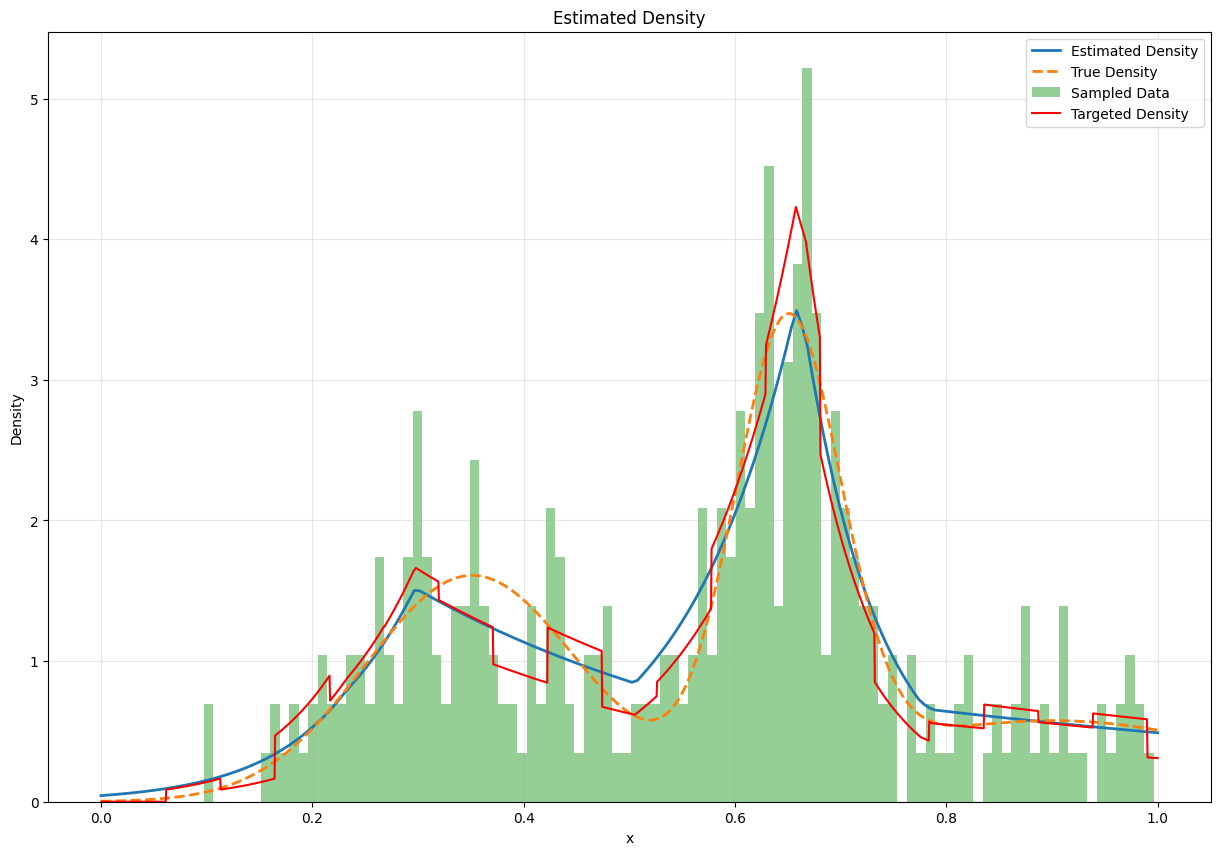

In [8]:
density_est_plot = plot_density(
    grid_points=grid_points,
    true_density=sampler.compute_density(grid_points),
    estimated_density=estimator.get_density_at_points(grid_points),
    title="Estimated Density",
    method_label="Estimated Density",
    show=False,
    figsize=(15, 10)
)

ax = density_est_plot.gca()
ax.hist(
    data["W1"], 
    bins=100, 
    density=True, 
    alpha=0.5, 
    label="Sampled Data"
)

ax.plot(
    targeted_fit['grid_midpoints'],
    targeted_fit['estimated_density'],
    label="Targeted Density",
    color='red',
)
ax.legend()

density_est_plot.show()

Estimated Survival statistic: array
True Survival statistic: array
Raw estimated Survival statistic: array
Standard errors shape: (20,)


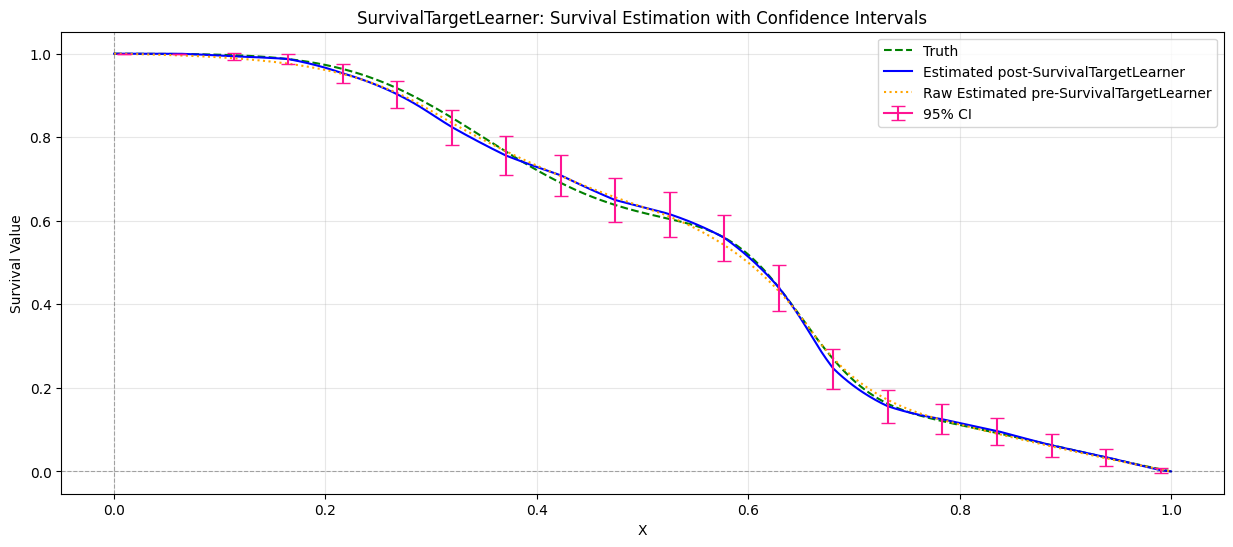

In [9]:
# 1. Compute statistic from targeted density
grid_points = targeted_fit['grid_midpoints']

stats, grid_points = statistic_from_density(
    grid_points=grid_points,
    density=targeted_fit['estimated_density'],
)

# True statistic for comparison
stats_true, _ = statistic_from_density(
    grid_points=grid_points,
    density=sampler.compute_density(grid_points),
)

# Raw estimated statistic (before targeting)
raw_density_est = BaseEstimator.calculate_density_at_points(
    points=grid_points,
    theta_hat=theta_selected,
    basis_grid_points=grid_points_hal_selected,
    basis_order=estimator_basis_order
)

stats_raw, _ = statistic_from_density(
    grid_points=grid_points,
    density=raw_density_est,
)

# 2. Estimate variances
variance_kwargs = targeting_kwargs.copy()
if TARGET_TYPE == "Median":
    variance_kwargs = {}
elif TARGET_TYPE == "Moments":
    variance_kwargs = {'x_moment': moment_order}

variances = estimand_variance(
    targeted_fit=targeted_fit,
    uncensored_data=data,
    **variance_kwargs
)

# 3. Get standard errors for confidence intervals
standard_errors = np.sqrt(variances)

print(f"Estimated {TARGET_TYPE} statistic: {stats if isinstance(stats, float) else 'array'}")
print(f"True {TARGET_TYPE} statistic: {stats_true if isinstance(stats_true, float) else 'array'}")
print(f"Raw estimated {TARGET_TYPE} statistic: {stats_raw if isinstance(stats_raw, float) else 'array'}")
print(f"Standard errors shape: {standard_errors.shape}")

# 4. Plot statistic with confidence intervals
plt.figure(figsize=(15, 6))

# For scalar statistics (Moments, Median), plot as vertical bands at the statistic value
if isinstance(stats, (float, np.floating)) or (isinstance(stats, np.ndarray) and stats.size == 1):
    scalar_stat = float(stats)
    scalar_stat_true = float(stats_true)
    scalar_stat_raw = float(stats_raw)
    scalar_se = float(standard_errors)

    # Vertical lines for point estimates
    plt.axvline(x=scalar_stat_true, label='Truth', color='green', linestyle='--')
    plt.axvline(x=scalar_stat, label=f'Estimated post-{TargetLearner.__name__}', color='blue')
    plt.axvline(x=scalar_stat_raw, label=f'Raw Estimated pre-{TargetLearner.__name__}', color='orange', linestyle=':')

    # Vertical confidence band around the estimate
    ci_left = scalar_stat - 1.96 * scalar_se
    ci_right = scalar_stat + 1.96 * scalar_se
    plt.axvspan(ci_left, ci_right, alpha=0.25, color='pink', label='95% CI')

    plt.xlabel('X')
    plt.ylabel(f'{TARGET_TYPE} Value')
    plt.xlim(0, 1)
else:
    # For function statistics (CDF, Survival), plot over grid
    plt.plot(grid_points, stats_true, label=f'Truth', color='green', linestyle='--')
    plt.plot(grid_points, stats, label=f'Estimated post-{TargetLearner.__name__}', color='blue')
    plt.plot(grid_points, stats_raw, label=f'Raw Estimated pre-{TargetLearner.__name__}', color='orange', linestyle=':')
    
    # Plot confidence intervals at targeting points
    if targeting_points is not None:
        for i, point in enumerate(targeting_points):
            stat_idx = np.searchsorted(grid_points, point)
            stat_i = stats[stat_idx]
            plt.errorbar(
                point, 
                stat_i, 
                yerr=1.96 * standard_errors[i], 
                color='deeppink', 
                capsize=5,
                label='95% CI' if i == 0 else ""
            )
    plt.xlabel('X')
    plt.ylabel(f'{TARGET_TYPE} Value')

plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.3)
plt.title(f'{TargetLearner.__name__}: {TARGET_TYPE} Estimation with Confidence Intervals')
plt.grid(alpha=0.3)
plt.legend()
plt.show()